In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *
from warpPlot import *

# This library
from warpSPH import *

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [14]:
nx = 128
dim = 2
L = 2 
n_h = 4
targetDt = 0.0005

gamma = 5/3
rho0 = 1
nu_visc = 0.0005
freeSurface = False

octaves = 3
lacunarity = 2
persistence = 0.5
baseFrequency = 2
tileable = True
kind = 'perlin'
seed = 45906734
obstacle = False

extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
    'nu_visc': nu_visc,

    'octaves': octaves,
    'lacunarity': lacunarity,
    'persistence': persistence,
    'baseFrequency': baseFrequency,
    'tileable': tileable,
    'kind': kind,
    'seed': seed,
    'obstacle': obstacle
}

In [15]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()


dx = L / (nx)
band = 0

domain = buildDomainDescription(L + dx * (band) * 2, dim, True, device, dtype)
interiorDomain = buildDomainDescription(L, dim, False, device, dtype)

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.dx = dx
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.surfaceDetectionConfig.active = freeSurface


In [16]:
fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)
domain_sdf = lambda x: sampleDomainSDF(x, interiorDomain, invert = False)
obstacle_sdf = lambda points: sampleSDF(points, lambda x: getSDF('circle')['function'](x, torch.tensor(1/4).to(points.device)), invert = False)

regions = []

regions.append(buildRegion(config, schemeConfig, fluid_sdf, RegionType.Fluid, initialConditions = {}))
# regions.append(buildRegion(config, schemeConfig, domain_sdf, RegionType.Boundary, initialConditions = {}, kind = BCType.freeSlip))
if obstacle:
    regions.append(buildRegion(config, schemeConfig, obstacle_sdf, RegionType.Boundary, initialConditions = {}, kind = BCType.freeSlip))


for region in regions:
    region = filterRegion(region, regions)
config.regions = schemeConfig.regions = regions

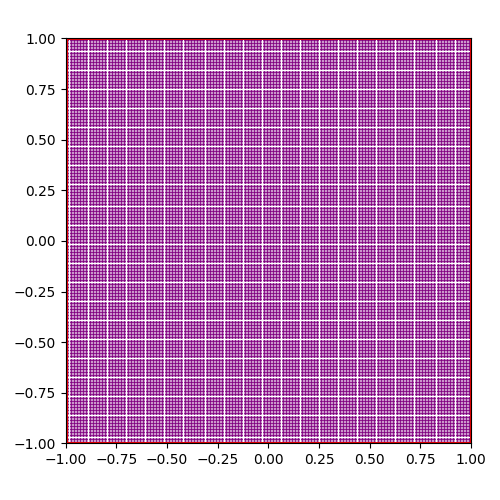

In [17]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

import matplotlib.patches as patches

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [18]:
compressibleSystem = initializeWeaklyCompressibleSimulation(regions, config, schemeConfig, SimulationSystem, SimulationState, verbose = True)

# compressibleSystem.state.positions = shuffleParticles(compressibleSystem.state, config, schemeConfig, 128, jitterAmount = 1.0)


schemeConfig.fluid.fixedSoundSpeed, config.dt = setupWeaklyCompressibleTimestep(config, schemeConfig, compressibleSystem, targetDt, verbose = True)
print(f"Computed timestep: {config.dt:.6g}, target timestep: {targetDt:.6g}, diff: {abs(config.dt - targetDt):.6g}")

Computed c0: 17.271244667215353, target c0: 10.0, diff: 7.271244667215353
Computed dt: 0.0005000000237487257, target dt: 0.0005, diff: 0.0
Max velocity: 0.0, CFL: 0.0, Max Mach: 0.0
Computed timestep: 0.0005, target timestep: 0.0005, diff: 0


In [19]:
from warpSPH.modules.noise.sampleDivergenceFree import generateNoiseInterpolator

nxGrid = nx * 2
domain_cpu = buildDomainDescription(L + dx * (band) * 2, dim, True, torch.device('cpu'), dtype)

noiseGen = generateNoiseInterpolator(nxGrid, nxGrid, domain_cpu, dim = domain.dim, octaves = octaves, lacunarity = lacunarity, persistence = persistence, baseFrequency = baseFrequency, tileable = tileable, kind = kind, seed = seed)

xi = 1
k = 4
noiseLevel = 0.01

In [55]:
def forcing(state, config, compParams, x, d, n, t, dt):
# def forcing(x, mask, state, t, dt):
    pos = getPeriodicPositions(x, domain)
    noiseOffset = torch.rand(pos.shape[1], device = device, dtype = dtype) * L - L/2
    noisePos = getPeriodicPositions(x + noiseOffset, domain)
    u_x = xi * torch.sin(k * np.pi * pos[:,1])
    u_y = noiseGen(pos.detach().cpu()).to(dtype = x.dtype, device = x.device) * noiseLevel
    return torch.stack([u_x, u_y], dim = 1) * state.masses.unsqueeze(1)

kolmogorovForcing = BoundaryCondition(
    type = BoundaryConditionType.dynamic,
    sdf = lambda x: fluid_sdf(x),
    forcingFunctions = [forcing]
)
schemeConfig.boundaryConditions = [kolmogorovForcing]

In [56]:
# forcingRegion = buildRegion(config, schemeConfig, fluid_sdf, RegionType.Fluid)
# forcingRegion.forcingFunction = [forcing]

# config.regions.append(forcingRegion)

# forcingValues = computeForcing(compressibleSystem, config.dt, compressibleSystem.t, config, schemeConfig)
# 
# print(f"Computed forcing: {forcingValues.mean().item():.6g}, max: {forcingValues.max().item():.6g}, min: {forcingValues.min().item():.6g}")

In [58]:
runningState = compressibleSystem.initializeNewState()

caseName = 'kolmogorov-flow'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'frame_num': 0,
}, **extraData))

In [61]:

markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B":runningState.state.UIDs,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # boundaryVisualization= VisualizeOptions.Visualize
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = CyclicColorMap.twilight,
            # colorMap = UniformColorMap.viridis,
            # flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "UIDs",
            # boundaryVisualization= VisualizeOptions.Visualize,
            fluidVisualization= VisualizeOptions.Visualize
            # vMin = 0.99,
            # vMax = 1.01
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (10,4),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)



RFBOutputContext()

In [62]:
schemeConfig.diffusionParams.inviscid = False
schemeConfig.diffusionParams.viscidNu = 0.005

nu = schemeConfig.diffusionParams.viscidNu if schemeConfig.diffusionParams.inviscid == False else alphaToNu(schemeConfig.diffusionParams.inviscidAlpha, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
alpha = nuToAlpha(schemeConfig.diffusionParams.viscidNu, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim) if schemeConfig.diffusionParams.inviscid == False else schemeConfig.diffusionParams.inviscidAlpha

print(f'Using inviscid: {schemeConfig.diffusionParams.inviscid}, nu: {nu:.6g}, alpha: {alpha:.6g}')

u_mag = 1
Re = u_mag / nu * (domain.max[0].cpu().item() - domain.min[0].cpu().item()) / 2
print(f"Reynolds number: {Re:.6g}\nnu: {nu:.6g} (alpha: {alpha:.6g})\nu_mag: {u_mag:.6g}, L: {(domain.max[0].cpu().item() - domain.min[0].cpu().item()) / 2:.6g}")
if alpha < 0.01:
    print(f'Running with a viscosity of alpha < 0.01 may result in unstable simulations.')
nu_limit = alphaToNu(0.01, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
Re_limit = u_mag / nu_limit * (domain.max[0].cpu().item() - domain.min[0].cpu().item()) / 2
print(f'Reynolds limit based on alpha = 0.01, nu = {nu_limit:.6g}, Re = {Re_limit:.6g}')

Using inviscid: False, nu: 0.005, alpha: 0.0370558
Reynolds number: 200
nu: 0.005 (alpha: 0.0370558)
u_mag: 1, L: 1
Reynolds limit based on alpha = 0.01, nu = 0.00134932, Re = 741.116


In [63]:
t_limit = 10.0
nSteps = int(t_limit / config.dt)

runningState = compressibleSystem.initializeNewState()

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state

    currentState = runningState.state
    # print(f'-' * 80)
    # print(f'Fluid density stats: min={currentState.densities[currentState.kinds == 0].min().item()}, max={currentState.densities[currentState.kinds == 0].max().item()}, mean={currentState.densities[currentState.kinds == 0].mean().item()}')
    # print(f'Boundary density stats: min={currentState.densities[currentState.kinds == 1].min().item()}, max={currentState.densities[currentState.kinds == 1].max().item()}, mean={currentState.densities[currentState.kinds == 1].mean().item()}')
    if i % 10 == 0 :
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.UIDs,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
    # break
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/19999 [00:00<?, ?it/s]

Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 9.41 ms  (cached)
Module sphWarpCore.renorm.wp_covariance aa33657 load on device 'cuda:0' took 9.79 ms  (cached)
Module sphWarpCore.operations.wp_gradient 77e4101 load on device 'cuda:0' took 12.36 ms  (cached)
Module warpSPH.modules.deltaSPH.wp_densityDelta 87a4618 load on device 'cuda:0' took 7.70 ms  (cached)
Module warpSPH.modules.deltaSPH.wp_viscosityDelta 16e5aa1 load on device 'cuda:0' took 10.20 ms  (cached)
Module sphWarpCore.operations.wp_divergence a5da11f load on device 'cuda:0' took 8.45 ms  (cached)
Module warpSPH.modules.pressure.wp_surfaceAware 97c665c load on device 'cuda:0' took 7.58 ms  (cached)
Module warpSPH.modules.util.wp_numNeighbors 06568d7 load on device 'cuda:0' took 8.80 ms  (cached)
Module warpSPH.sample.wp_deltaShift 5178276 load on device 'cuda:0' took 9.35 ms  (cached)


In [ ]:
# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'kineticEnergy': kineticEnergy,
#     'thermalEnergy': thermalEnergy,
#     'totalEnergy': totalEnergy,
#     'frame_num': i,
# }))

In [64]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# # now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

'export/kolmogorov-flow/output.mp4'

We can run a convergence test to see how the viscosity scales as well:

In [43]:
nu_tests = np.logspace(-1, -5, base=10, num=10)
test_data = []

for nu in tqdm(nu_tests, desc="Testing viscosities", leave=False):
    t_limit = 2.0
    nSteps = int(t_limit / config.dt)

    runningState = compressibleSystem.initializeNewState()
    schemeConfig.diffusionParams.viscidNu = nu

    kes = []
    priorStep = None
    for i in (tq := tqdm(range(nSteps), leave = False)):
        begin = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        begin.record()
        result = integrator.function(
            state = runningState,
            f = fn,
            dt = config.dt,  
            config = config,
            schemeConfig = schemeConfig,
            verbose = False,
            priorStep = priorStep
        )
        kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
        # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
        end.record()
        torch.cuda.synchronize()
        priorStep = result.stages[-1]
        timing = begin.elapsed_time(end)

        runningState = result.state

        if i % 60 == 0 and i > 0:
            plotter.updateQuantities(
                {
                    "A": runningState.state.velocities,
                    "B": runningState.state.densities,
                },
                newParticleState = runningState.state,
            )
            
        maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
        tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
        # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
        # break
        if torch.any(torch.isnan(runningState.state.velocities)):
            print("NaN detected in velocities, stopping simulation.")
            breakts = np.arange(len(kes)) * config.dt.cpu().item()
    kineticEnergy = np.array([ke.cpu().item() for ke in kes])
    E_k0 = kineticEnergy[0]

    # Fit an effective viscosity from d/dt log(E_k) = -4 * (ktgv**2) * nu_eff
    mask = (ts > 0) & (kineticEnergy > 0)
    slope = np.polyfit(ts[mask], np.log(kineticEnergy[mask] / E_k0), 1)[0]
    nu_eff = -slope / (4 * ktgv**2)

    test_data.append({
        'nu': nu,
        'nu_eff': nu_eff,
        'nu_diff': abs(nu_eff - nu),
        'nu_rel_diff': abs(nu_eff - nu) / nu,
        'E_k0': E_k0,
        'kineticEnergy': kineticEnergy,
        'ts': ts,
    })


Testing viscosities:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

...

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

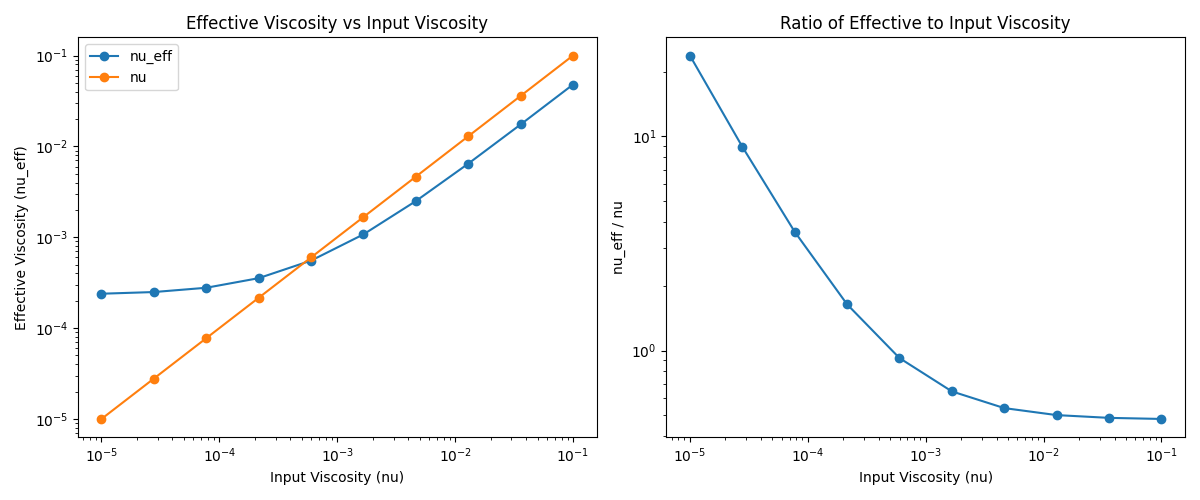

In [45]:
fig, axis = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)

nus = np.array([data['nu'] for data in test_data])
nu_effs = np.array([data['nu_eff'] for data in test_data])
axis[0,0].loglog(nus, nu_effs, marker='o', label='nu_eff')
axis[0,0].loglog(nus, nus, marker='o', label='nu')
axis[0,0].set_xlabel('Input Viscosity (nu)')
axis[0,0].set_ylabel('Effective Viscosity (nu_eff)')
axis[0,0].set_title('Effective Viscosity vs Input Viscosity')
axis[0,0].legend()

axis[0,1].loglog(nus, nu_effs / nus, marker='o')
axis[0,1].set_xlabel('Input Viscosity (nu)')
axis[0,1].set_ylabel('nu_eff / nu')
axis[0,1].set_title('Ratio of Effective to Input Viscosity')

fig.tight_layout()

fig.savefig('nu_eff_vs_nu.png', dpi=300)
